# Evaluate clustering goodness-of-fit by scDesign3

This notebook reimplements the scDesign3 clustering goodness-of-fit vignette.

In [1]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/pyl/anaconda3/envs/scdesigner/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <20FB70DB-7E84-3375-A520-E0350E06C060> /Users/pyl/anaconda3/envs/scdesigner/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [4]:
%%R
suppressPackageStartupMessages({
  library(DuoClustering2018)
  library(SingleCellExperiment)
  library(scran)
  library(dplyr)
  library(zellkonverter)
  library(ggplot2)
  library(aricode)
})
theme_set(theme_bw())

In [5]:
%%R
set.seed(123)

Zhengmix4eq_sce <- get("sce_filteredExpr10_Zhengmix4eq")(metadata = FALSE)
res <- get("clustering_summary_filteredExpr10_Zhengmix4eq_v1")(metadata = FALSE)

res_sub <- res %>%
  filter(
    method %in% c("SC3", "Seurat", "PCAHC", "PCAKmeans", "CIDR"),
    run == 1
  )

res_sub_list <- res_sub %>%
  group_by(dataset, method, run, k, resolution) %>%
  group_split()

kmeans_res <- Filter(function(x) all(x$method == "PCAKmeans"), res_sub_list)
ncell <- ncol(Zhengmix4eq_sce)
ngene <- 100
zheng_sce <- modelGeneVar(Zhengmix4eq_sce)
chosen <- getTopHVGs(zheng_sce, n = ngene)
sce <- Zhengmix4eq_sce[chosen, ]
ntrain <- round(ncell/2)

train_index <- sample(seq_len(ncell), ntrain, replace = FALSE)
train_sce <- sce[, train_index]

for (x in kmeans_res) {
  dat <- x %>% dplyr::select(c("cell", "cluster")) %>% data.frame()
  rownames(dat) <- dat$cell
  colData(train_sce)$cell_type <- factor(dat[colnames(train_sce), ]$cluster)
  k <- unique(x$k)[1]
  writeH5AD(train_sce, paste0("data/clustering_", k, "_gof_sce.h5ad"))
}

kmeans_ari <- data.frame(ari = unlist(lapply(kmeans_res, function(x){ARI(x$cluster, x$trueclass)})))
write.csv(kmeans_ari, "data/kmeans_ari.csv", row.names = FALSE)

/Users/pyl/Library/Caches/org.R-project.R/R/basilisk/1.16.0/zellkonverter/1.14.1/zellkonverterAnnDataEnv-0.10.6/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/pyl/Library/Caches/org.R-project.R/R/basilisk/1.16.0/zellkonverter/1.14.1/zellkonverterAnnDataEnv-0.10.6/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/pyl/Library/Caches/org.R-project.R/R/basilisk/1.16.0/zellkonverter/1.14.1/zellkonverterAnnDataEnv-0.10.6/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/pyl/Library/Caches/org.R-project.R/R/basilisk/1.16.0/zellkonverter/1.14.1/zellkonverterAnnDataEnv-0.10.6/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The 

see ?DuoClustering2018 and browseVignettes('DuoClustering2018') for documentation
loading from cache
see ?DuoClustering2018 and browseVignettes('DuoClustering2018') for documentation
loading from cache


Now we load the training data in Python. The cluster assignments for k = 2, ..., 10 are stored as `cell_type` metadata. For each clustering, we use the `cell_type` covariate in the mean and dispersion formulas. The fitted simulator is sampled once under the same observation design, and the ARI are already calculated against the ground-truth `true_class` labels.

In [6]:
from scdesigner.simulators import NegBinCopula
import numpy as np
import pandas as pd
import anndata

np.random.seed(123)

rows = []
for k in range(2, 11):
    cluster_key = f"cluster_{k}"
    sce = anndata.read_h5ad(f"data/clustering_{k}_gof_sce.h5ad")

    sim = NegBinCopula(
        mean_formula="~ cell_type",
        dispersion_formula="~ cell_type",
        copula_formula="~ 1",
    )
    sim.fit(sce)
    metrics = sim.complexity()

    marginal_bic = float(metrics["marginal_bic"])
    copula_bic = float(metrics["copula_bic"])
    rows.append(
        {
            "bic_marginal": marginal_bic,
            "bic_copula": copula_bic,
            "bic_total": marginal_bic + copula_bic,
        }
    )

metric = pd.DataFrame(rows)
metric

Epoch 299/500, Loss: 1.5535, Val Loss: 1.5685


Computing log-likelihood...: 100%|██████████| 2/2 [00:00<00:00,  6.68it/s]


Epoch 227/500, Loss: 1.4191, Val Loss: 1.4642


Computing log-likelihood...: 100%|██████████| 2/2 [00:00<00:00,  8.71it/s]


Epoch 230/500, Loss: 1.4211, Val Loss: 1.4648


...

Epoch 211/500, Loss: 1.3635, Val Loss: 1.4124


Computing log-likelihood...: 100%|██████████| 2/2 [00:00<00:00,  8.21it/s]


Epoch 172/500, Loss: 1.3508, Val Loss: 1.3828


Computing log-likelihood...: 100%|██████████| 2/2 [00:00<00:00,  7.74it/s]


,bic_marginal,bic_copula,bic_total
0,555994.672766,-48484.765824,507509.906942
1,510801.009150,-16849.459159,493951.549991
2,512945.251783,-17291.014514,495654.237269
3,509215.400666,-15308.015548,493907.385118
4,493191.424549,-5521.929761,487669.494788
5,501268.448433,-8473.649444,492794.798988
6,501584.316066,-7768.266873,493816.049192
7,500147.402449,-7089.267277,493058.135172
8,496526.801332,-4793.243622,491733.557711


As in the scDesign3 vignette, we can compare the unsupervised BIC with the supervised ARI. Lower marginal BIC indicates a better fit under the simulator.

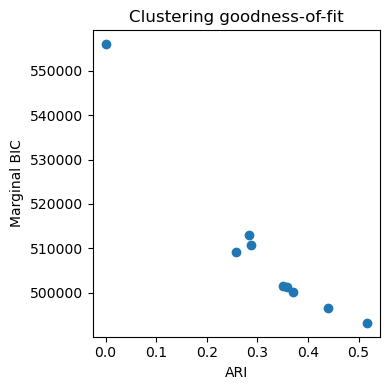

In [7]:
import matplotlib.pyplot as plt

ari = pd.read_csv("data/kmeans_ari.csv")

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(ari["ari"], metric["bic_marginal"])

ax.set_xlabel("ARI")
ax.set_ylabel("Marginal BIC")
ax.set_title("Clustering goodness-of-fit")
fig.tight_layout()